#  DSC680-T302 Applied Data Science #

## Week 12 -  Project 3 - Milestone 3 supporting ##

### Saravanan Janarthanan ###
-----

#### Summary ####
This project aims to evaluate the performance of a custom-built feedforward neural network on the IRIS and MNIST datasets. The goal is to explore how custom neural components like Dense layers, ReLU activations, and Batch Normalization perform compared to Keras and PyTorch implementations, particularly in terms of training behavior and validation loss.

In [1]:
# Flags to print chain of class invokation for the first time.
# Each flag is used within a custom implementaion functions ,  both common and within the class
sigmoid_invk = True
sigmoid_der_invk = True
relu_invk = True
relu_der_invk = True
softmax_invk = True
crs_entr_loss_invk = True
Dens_init_invk = True
Dens_frwd_invk = True
Dens_bkwd_invk = True
NN_init_invk = True
NN_fwd_invk = True
NN_bkwd_invk = True
BN_init_invk = True
BN_fwd_invk = True
BN_bkwd_invk = True
DrpLyr_init_invk = True
DrpLyr_fwd_invk = True
DrpLyr_bkwd_invk = True

## 🔁 Common Functions Overview

---

### **Sigmoid Function**
The **sigmoid** activation function is an S-shaped curve defined as:

\[
\sigma(x) = \frac{1}{1 + e^{-x}}
\]

- Maps any real-valued number into a range between **0 and 1**.
- Commonly used in binary classification tasks.
- Also useful in output layers to represent probabilities.

---

### **Sigmoid Derivative**

\[
\sigma'(x) = x(1 - x)
\]

- Assumes `x` has already been passed through the sigmoid function.
- Used during backpropagation to compute gradients.
- May lead to **vanishing gradients** in deep networks when values become very small.

---

### **ReLU (Rectified Linear Unit)**

\[
\text{ReLU}(x) = \max(0, x)
\]

- Returns the input if it is positive, otherwise returns 0.
- Efficient and widely used in hidden layers of deep networks.
- Helps prevent vanishing gradients in positive domain.

---

### **ReLU Derivative**

\[
\text{ReLU}'(x) =
\begin{cases}
1 & \text{if } x > 0 \\
0 & \text{if } x \leq 0
\end{cases}
\]

- Simple to compute and enables fast training.
- May lead to **dead neurons** where neurons stop activating if they receive only negative inputs.

---

### **Softmax Function**

\[
\text{softmax}(x_i) = \frac{e^{x_i}}{\sum_j e^{x_j}}
\]

- Converts raw score vectors into probabilities.
- Applied **row-wise** for stability.
- Used in the **output layer** for multi-class classification problems.
- Output values are between 0 and 1 and sum to 1.

---

### **Cross-Entropy Loss**

\[
L = -\frac{1}{m} \sum (y_{\text{true}} \cdot \log(y_{\text{pred}}))
\]

- Measures the performance of classification models with probabilistic outputs.
- Higher loss if predicted probability is far from actual.
- Often used with **softmax** for multi-class classification.

---

### **One-Hot Encoding**

- Transforms class labels into binary vectors.
- Example: Label `2` in a 4-class problem → `[0, 0, 1, 0]`.
- Required for loss functions like cross-entropy that expect categorical data in vector format.

---


In [2]:
import numpy as np

# Activation Functions
def sigmoid(x):
    global sigmoid_invk
    if(sigmoid_invk):
        print("Inside Gen: sigmoid(x) function")
        sigmoid_invk = False
    return 1 / (1 + np.exp(-x))

def sigmoid_derivative(x):
    global sigmoid_der_invk
    if(sigmoid_der_invk):
        print("Inside Gen: sigmoid_derivative(x) function")
        sigmoid_der_invk = False    
    return x * (1 - x)

def relu(x):
    global relu_invk
    if(relu_invk):
        print("Inside Gen: relu(x) function")
        relu_invk = False
    return np.maximum(0, x)

def relu_derivative(x):
    global relu_der_invk
    if(relu_der_invk):
        print("Inside Gen: relu_derivative(x) function")
        relu_der_invk = False
    return (x > 0).astype(float)

def softmax(x):
    global softmax_invk
    if(softmax_invk):
        print("Inside Gen: softmax(x) function")
        softmax_invk = False
    exp_x = np.exp(x - np.max(x, axis=1, keepdims=True))  # for numerical stability
    return exp_x / np.sum(exp_x, axis=1, keepdims=True)

# Loss Function
def cross_entropy_loss(y_true, y_pred):
    global crs_entr_loss_invk
    if(crs_entr_loss_invk):
        print("Inside Gen: cross_entropy_loss(x) function")
        crs_entr_loss_invk = False
    m = y_true.shape[0]
    epsilon = 1e-12
    y_pred = np.clip(y_pred, epsilon, 1. - epsilon)
    return -np.sum(y_true * np.log(y_pred)) / m

def one_hot_encode(y, num_classes):
    print("Inside Gen: one_hot_encode(x) function")
    return np.eye(num_classes)[y]

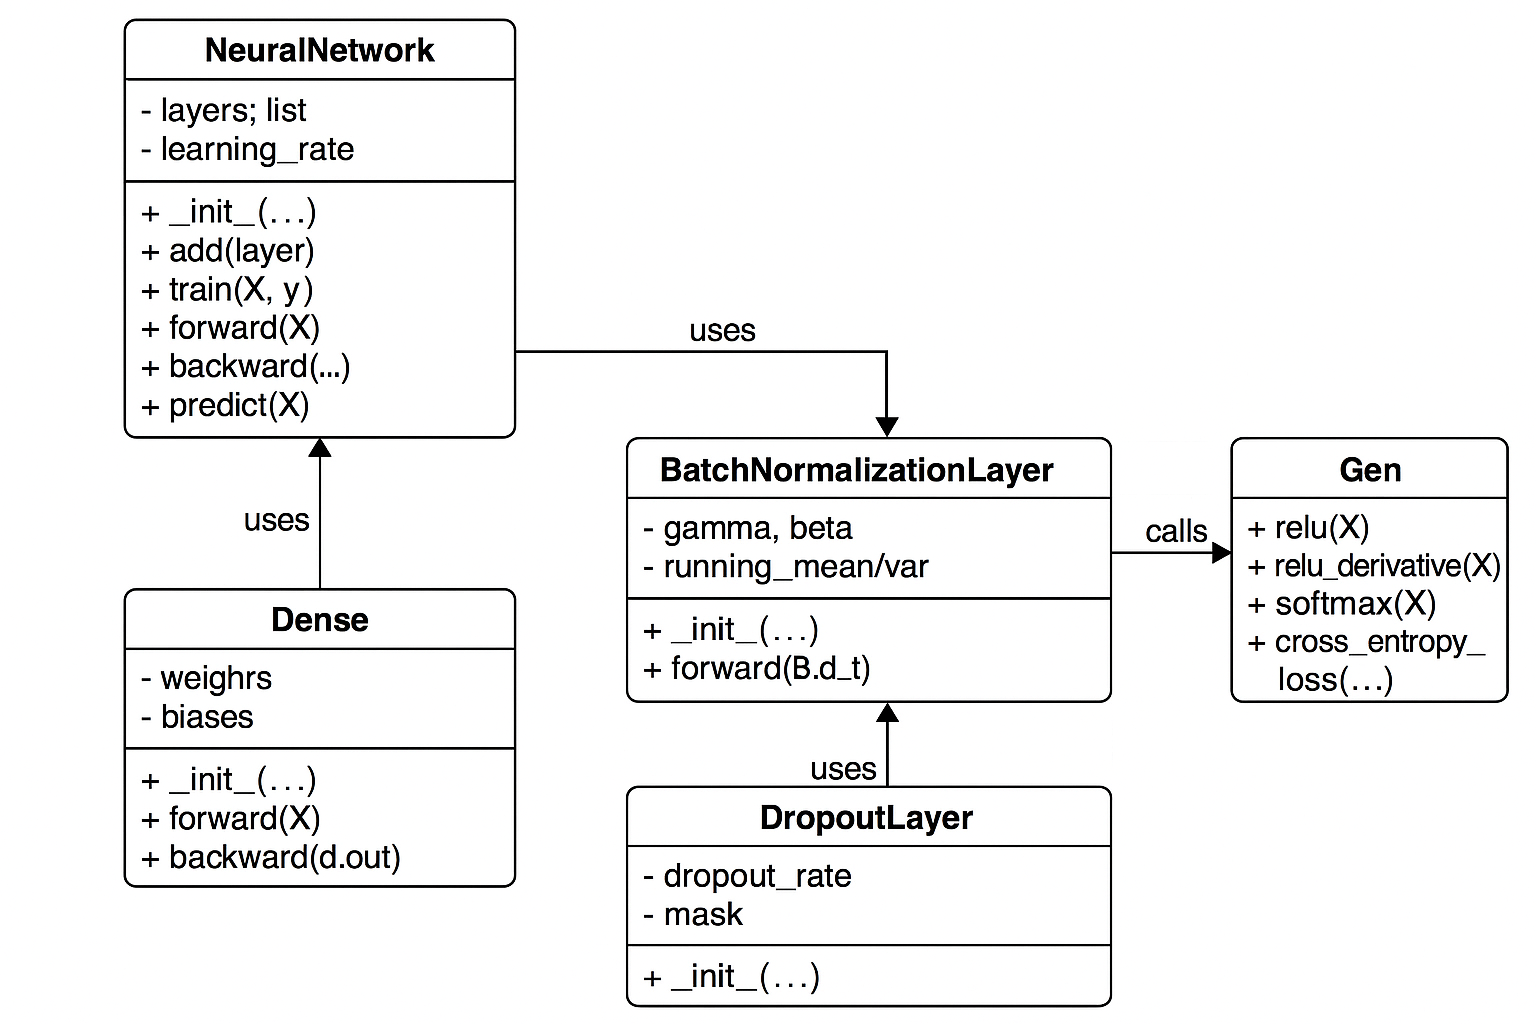

#### Dense_Custom Class ####
The Dense_Custom class represents a fully connected neural network layer. It initializes with randomly generated weights and zero biases, and it supports user-defined activation functions like ReLU or softmax. During the forward pass, it performs a linear transformation followed by activation. In the backward pass, it calculates gradients of the loss with respect to weights, biases, and inputs, updating parameters via gradient descent. It plays a central role in learning by adjusting its internal weights based on the received error signal.

__init__()
- Initializes weights (random small values), biases (zeros), and activation.

**forward()**
- Stores input.
- Calculates Z = x @ weights + bias.
- Applies activation (ReLU, sigmoid, softmax).
- Returns output.

**backward()**
- Computes gradients:
- dW = (input.T @ dZ) / m
- dB = np.mean(dZ, axis=0)
- Applies activation derivative if needed.
- Updates weights and biases.
- Returns gradient to previous layer: d_input = dZ @ weights.T

In [3]:
# Dense_Custom (Fully Connected) Layer
class Dense_Custom:
    def __init__(self, input_dim, output_dim, activation=None):
        print("Inside Dense_Custom classs : __init__(x) function")
        # Initilize weights, with a shape equivalent to input and output data structure,  with random values scaled down 
        self.weights = np.random.randn(input_dim, output_dim) * 0.01
         # Initilize biases, with a shape equivalent to input and with value 1 filled in
        self.biases = np.zeros((1, output_dim))
        # set the activiation function name chosen for the layer
        self.activation_name = activation

        #based on the activation name set activation fuction and derivative method signatures
        if activation == 'sigmoid':
            self.activation = sigmoid
            self.activation_derivative = sigmoid_derivative
        elif activation == 'relu':
            self.activation = relu
            self.activation_derivative = relu_derivative
        elif activation == 'softmax':
            self.activation = softmax
            self.activation_derivative = None  # handled in loss
        else:
            raise ValueError("Unsupported activation")


    
    # Forward pass 
    # processes input data passed from the Neural Network (if it’s the first layer) 
    # or from the previous layer (if it's an intermediate or output layer).
    def forward(self, input_data, training=True):
        global Dens_frwd_invk
        if(Dens_frwd_invk):
            print("Inside Dense_Custom classs : forward(x) function")
            Dens_frwd_invk = False   
        # store input data to be used in backward pass    
        self.input = input_data
        # matrix multiplication is performed between the input data and the layer’s weight matrix   and adding biases
        self.z = np.dot(input_data, self.weights) + self.biases
        # use the activiation function to get 0 to 1 or avoid negative values based on activation function
        self.a = self.activation(self.z)
        return self.a


    # backward pass (backward propogation) 
    # performs the backward pass for a Dense (fully connected) layer during training. 
    # It computes gradients and updates weights and biases using gradient descent.
    def backward(self, dA, learning_rate):
        global Dens_bkwd_invk
        if(Dens_bkwd_invk):
            print("Inside Dense_Custom classs : backward(x) function")
            Dens_bkwd_invk = False
        # get input data length    
        m = self.input.shape[0]

        # Process incoming gradients based on activation function 
        if self.activation_name in ['sigmoid', 'relu']:
            dZ = dA * self.activation_derivative(self.a)
        else:  # Softmax + cross-entropy simplified gradient
            dZ = dA

        # Gradient of the loss with respect to Weights  
        dW = np.dot(self.input.T, dZ) / m
        # Gradient of the loss with respect to biases 
        dB = np.sum(dZ, axis=0, keepdims=True) / m

        # Compute the gradient of the loss with respect to the input by multiplying 
        # the current layer’s gradient with the transposed weight matrix 
        # (either initialized or updated), and returns it to the previous layer. 
        d_input = np.dot(dZ, self.weights.T)

        # Gradient descent update
        self.weights -= learning_rate * dW
        self.biases -= learning_rate * dB
        return d_input


 #### NeuralNetwork Class ####
 
The NeuralNetwork class serves as the backbone of the custom model, managing the entire training process. It initializes with a specified learning rate and allows users to add layers such as Dense, Batch Normalization, and Dropout. The forward() method sequentially passes data through each layer to generate predictions, while the backward() method propagates errors in reverse to update parameters. The train() method handles batch-based training over multiple epochs, calculating loss and coordinating updates across all layers.

__init__()
- Initializes the model with specified learning rate.

**add()**
- Adds a custom layer (Dense, BatchNorm, Dropout) to the model.

**forward()**
- Passes inputs sequentially through layers to generate predictions.

**backward( )**
- Computes error and calls backward methods on each layer in reverse.

**train()**
- Trains model over epochs and batches using forward & backward passes.

In [4]:
# Neural Network Using Dense Layers
class NeuralNetwork:
    # Class constructre method 
    def __init__(self, learning_rate=0.1):
        print("Inside NeuralNetwork classs : __init__(x) function")
        self.layers = []
        # Initilaize the learning rate
        self.learning_rate = learning_rate

    # Add layers to netwrok (can be Dense_custom,  BatchNormalization_custom and Dropout_custom classes
    def add(self, layer):
        print("Inside NeuralNetwork classs : add(x) function")
        #  add each class to the list
        self.layers.append(layer)

    # Forward pass that follows chain of rule 
    # Passes inputs sequentially through layers to generate predictions.
    def forward(self, X, training=True):
        global NN_fwd_invk
        if NN_fwd_invk:
            print("Inside NeuralNetwork classs : forward(x) function")
            NN_fwd_invk = False
        # Feed forward the refined data from layer to another
        for layer in self.layers:
            X = layer.forward(X)
        return X

    # backwrad pass that follows chain of rule
    # Computes error and calls backward methods on each layer in reverse.
    # Propogates the erros and learning to previous layers 
    def backward(self, y_true, y_pred):
        global NN_bkwd_invk
        if NN_bkwd_invk:
            print("Inside NeuralNetwork classs : backward(x) function")
            NN_bkwd_invk = False
        dA = y_pred - y_true  # for softmax + cross-entropy
        # Iterate in reverse to pass on the loss
        for layer in reversed(self.layers):
            dA = layer.backward(dA, self.learning_rate)

    # Trains model over epochs and batches using forward & backward passes.
    # Orchestrate the forward and backward pass across batches and epochs
    def train(self, X, y, epochs=1000, batch_size=32, verbose=True): 

        print("Inside NeuralNetwork classs : train(x) function")
        
        num_samples = X.shape[0]
        # Repeat training over the full dataset for the specified number of epochs
        for epoch in range(epochs):
            # Shuffle data at the beginning of each epoch
            permutation = np.random.permutation(num_samples)
            X_shuffled = X[permutation]
            y_shuffled = y[permutation]
    
            epoch_loss = 0.0 # To accumulate loss for the epoch
            
            global batch_num
            
            verbose = False
            
            # Inner loop for mini-batches
            for i in range(0, num_samples, batch_size):
                batch_num = i
                # Pick the batch sample from the population
                X_batch = X_shuffled[i:i + batch_size]
                y_batch = y_shuffled[i:i + batch_size]
    
                # Forward pass (training mode) with  training is set to True
                y_pred_batch = self.forward(X_batch, training=True)
                     
    
                # Calculate loss
                current_batch_loss = cross_entropy_loss(y_batch, y_pred_batch)
                epoch_loss += current_batch_loss * X_batch.shape[0] # Accumulate sum of losses
    
                # Backward pass and update weights
                self.backward(y_batch, y_pred_batch)
    
            epoch_loss /= num_samples # Get average loss for the epoch

            # Print the loss and epoch details
            if verbose and ((epoch + 1) % 10 == 0 or epoch == 0): # Print every 10 epochs or first
                print(f"Epoch {epoch + 1}/{epochs}, Loss: {epoch_loss:.4f}")
            elif verbose and epoch + 1 == epochs: # Always print last epoch
                 print(f"Epoch {epoch + 1}/{epochs}, Loss: {epoch_loss:.4f}")

    def predict(self, X):
        print("Inside NeuralNetwork classs : predict(x) function")
        # call forward pass with training flag set to false to notify evaluation or inference mode
        y_pred = self.forward(X, training=False)
        return np.argmax(y_pred, axis=1)

    def predict_proba(self, X):
        # This method returns the raw probabilities (output of softmax)
        print("Inside NeuralNetwork classs : predict_proba(x) function")
        return self.forward(X, training=False)

#### BatchNormalizationLayer_custom Class ####
The BatchNormalizationLayer_custom class normalizes the input features to stabilize and speed up training. It maintains trainable scaling (gamma) and shifting (beta) parameters and tracks long-term statistics like running mean and variance. During training, it computes batch-wise mean and variance to normalize inputs, applies gamma and beta, and updates running stats. During inference, it uses the stored running values. The backward method calculates gradients with respect to the input, gamma, and beta, enabling fine-tuned learning of normalization parameters.

__init__()
- Initializes weights (random small values), biases (zeros), and activation.

**forward()**
- Stores input.
- Calculates Z = x @ weights + bias.
- Applies activation (ReLU, sigmoid, softmax).
- Returns output.

**backward()**
- Computes gradients:
- dW = (input.T @ dZ) / m
- dB = np.mean(dZ, axis=0)
- Applies activation derivative if needed.
- Updates weights and biases.
- Returns gradient to previous layer: d_input = dZ @ weights.T

In [5]:
class BatchNormalizationLayer_custom:
    # Initilizes epsilon, momemtun
    def __init__(self, input_dim, epsilon=1e-5, momentum=0.9):
        print("Inside BatchNormalizationLayer_custom classs : __init__(x) function")
        
        # constant added to avoid division to zero 
        self.epsilon = epsilon
        
        # used to update running_mean and running_var
        self.momentum = momentum
        
        # Trainable: gamma (scale, init to 1)
        self.gamma = np.ones((1, input_dim))
        
        # Trainable: beta (shift, init to 0)
        self.beta = np.zeros((1, input_dim))
        
        #store whole mean and variance across epochs
        self.running_mean = np.zeros((1, input_dim))
        self.running_var = np.ones((1, input_dim))



    # forward pass that is part of chain of rule 
    # use the input from prevous layer 
    def forward(self, x, training=True, verbose=False):
        global BN_fwd_invk
        if(BN_fwd_invk):
            print("Inside BatchNormalizationLayer_custom classs : forward(x) function")
            BN_fwd_invk = False
            
        # store the raw inout to be used in backward pass
        self.input = x

        # execute only if in training mode
        if training:
            # Calculate batch mean and batch variance 
            self.batch_mean = np.mean(x, axis=0, keepdims=True)
            self.batch_var = np.var(x, axis=0, keepdims=True)
            #obtain normailzed input using difference between data point and mean and divide by standard devition 
            self.x_norm = (x - self.batch_mean) / np.sqrt(self.batch_var + self.epsilon)
            # Scale normalized input by updated gamma and beta trained values
            self.out = self.gamma * self.x_norm + self.beta

            # update running stats
            self.running_mean = self.momentum * self.running_mean + (1 - self.momentum) * self.batch_mean
            self.running_var = self.momentum * self.running_var + (1 - self.momentum) * self.batch_var
        # during inference
        else:
            x_norm = (x - self.running_mean) / np.sqrt(self.running_var + self.epsilon)
            # Scale normalized input by updated gamma and beta trained values
            self.out = self.gamma * x_norm + self.beta
        
        return self.out

    

    # Backward pass to pass the error learning and gradient losses 
    def backward(self, d_out, learning_rate, verbose=False):
        global BN_bkwd_invk
        if(BN_bkwd_invk):
            print("Inside BatchNormalizationLayer_custom classs : backward(x) function")
            BN_bkwd_invk = False
        m = self.input.shape[0]
        # find the delta or gap between actuas values vs current batch mean value
        x_mu = self.input - self.batch_mean
        std_inv = 1. / np.sqrt(self.batch_var + self.epsilon)
        
        # Gradient of the loss with respect to normalized input
        d_x_norm = d_out * self.gamma
        
        # Gradient of the loss with respect to batch variance
        d_var = np.sum(d_x_norm * x_mu, axis=0, keepdims=True) * -0.5 * std_inv**3
        
        # Gradient of the loss with respect to the batch mean 
        d_mean = np.sum(d_x_norm * -std_inv, axis=0, keepdims=True) + d_var * np.mean(-2. * x_mu, axis=0, keepdims=True)
        
        # Final Gradient calculation for the backward pass 
        dx = d_x_norm * std_inv + d_var * 2 * x_mu / m + d_mean / m
        
        # Gradient of loss, d_gamma,  with respect to gamma 
        d_gamma = np.sum(d_out * self.x_norm, axis=0, keepdims=True)
        
        # gradient of the loss with respect to beta 
        d_beta = np.sum(d_out, axis=0, keepdims=True)

        # update gamma and beta with the error learnings and learning rate
        self.gamma -= learning_rate * d_gamma
        self.beta -= learning_rate * d_beta
            
        return dx





#### DropoutLayer_custom Class ####
The DropoutLayer_custom class reduces overfitting by randomly disabling a fraction of neurons during training. It uses a binary mask to deactivate certain neurons and scales the remaining outputs to maintain consistency. During inference, dropout is turned off, and data flows through unaltered. In the backward pass, the same mask is applied to the gradients to ensure only the "active" neurons contribute to weight updates. This simple but powerful technique improves model generalization, especially in deep architectures.

__init__()
- Stores dropout probability.

**forward()**
- During training:
- Creates binary mask (1: keep, 0: drop)
- Applies inverted dropout scaling: x * mask / (1 - rate)
- During inference:
- Passes input unchanged

**backward()**
- Applies same mask to gradients
- Scales gradients to match forward pass

In [6]:

class DropoutLayer_custom:
    def __init__(self, dropout_rate=0.5):
        print("Inside DropoutLayer_custom classs : __init__(x) function")
        # Initializes the dropout layer with a dropout rate (default: 0.5).
        self.dropout_rate = dropout_rate

    
    # Forward pass to drop neurons to avoid overfitting
    def forward(self, x, training=True, verbose=False):
        global DrpLyr_fwd_invk
        if(DrpLyr_fwd_invk):
            print("Inside DropoutLayer_custom classs : forward(x) function")
            DrpLyr_fwd_invk = False
        # During training Neurons are dropped
        if training:
            # mask neurons to aid dropout
            self.mask = (np.random.rand(*x.shape) > self.dropout_rate).astype(float)
            return x * self.mask / (1 - self.dropout_rate)
        # During inference no dropouts ,  data passes through
        else:
            return x  # no dropout during inference
        
    # backward pass to update the unmasked neurons 
    def backward(self, d_out, learning_rate=None, verbose=False):
        global DrpLyr_bkwd_invk
        if(DrpLyr_bkwd_invk):
            print("Inside DropoutLayer_custom classs : backward(x) function")
            DrpLyr_bkwd_invk = False
        # use the neurons marked in forward pass
        return d_out * self.mask / (1 - self.dropout_rate)



#### Training IRIS Data on a Custom Neural Network ####

The IRIS dataset, containing 150 flower samples across 3 classes and 4 features, serves as a simple and effective dataset for testing classification models. When training on a custom-built neural network, the data is first preprocessed—features are normalized, and class labels are one-hot encoded. The model is constructed using layers like Dense_Custom, BatchNormalizationLayer_custom, and DropoutLayer_custom to simulate a typical deep learning pipeline.

During training, the network performs forward passes to compute predictions and backward passes to adjust weights and other parameters based on loss gradients. The process is repeated over several epochs using mini-batches to optimize learning.

In [7]:
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, precision_score, f1_score, roc_curve, auc
import matplotlib.pyplot as plt


# Load and preprocess Iris dataset
iris = load_iris()
X = iris.data
y = iris.target
num_classes = len(np.unique(y))

# convert categorical to numerical values
y_encoded = one_hot_encode(y, num_classes)

# Feature scale the dependent variables 
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y_encoded, test_size=0.2, random_state=42
)

# Build and train model with ReLU
model = NeuralNetwork(learning_rate=0.1)
model.add(Dense_Custom(input_dim=4, output_dim=8, activation='relu'))
model.add(BatchNormalizationLayer_custom(input_dim=8))
model.add(DropoutLayer_custom(dropout_rate=0.3))
model.add(Dense_Custom(input_dim=8, output_dim=3, activation='softmax'))

model.train(X_train, y_train, epochs=1000)

# Evaluate model
y_train_pred_labels = model.predict(X_train)
y_test_pred_labels = model.predict(X_test)
y_train_pred_proba = model.predict_proba(X_train)
y_test_pred_proba = model.predict_proba(X_test)


y_train_true_labels = np.argmax(y_train, axis=1)
y_test_true_labels = np.argmax(y_test, axis=1)

print(f"\n--- Evaluation for Iris Dataset (Custom NN) ---")
print(f"Train Accuracy: {accuracy_score(y_train_true_labels, y_train_pred_labels):.2f}")
print(f"Test Accuracy: {accuracy_score(y_test_true_labels, y_test_pred_labels):.2f}")



Inside Gen: one_hot_encode(x) function
Inside NeuralNetwork classs : __init__(x) function
Inside Dense_Custom classs : __init__(x) function
Inside NeuralNetwork classs : add(x) function
Inside BatchNormalizationLayer_custom classs : __init__(x) function
Inside NeuralNetwork classs : add(x) function
Inside DropoutLayer_custom classs : __init__(x) function
Inside NeuralNetwork classs : add(x) function
Inside Dense_Custom classs : __init__(x) function
Inside NeuralNetwork classs : add(x) function
Inside NeuralNetwork classs : train(x) function
Inside NeuralNetwork classs : forward(x) function
Inside Dense_Custom classs : forward(x) function
Inside Gen: relu(x) function
Inside BatchNormalizationLayer_custom classs : forward(x) function
Inside DropoutLayer_custom classs : forward(x) function
Inside Gen: softmax(x) function
Inside Gen: cross_entropy_loss(x) function
Inside NeuralNetwork classs : backward(x) function
Inside Dense_Custom classs : backward(x) function
Inside DropoutLayer_custom

Test Precision (weighted): 0.97
Test F1-Score (weighted): 0.97


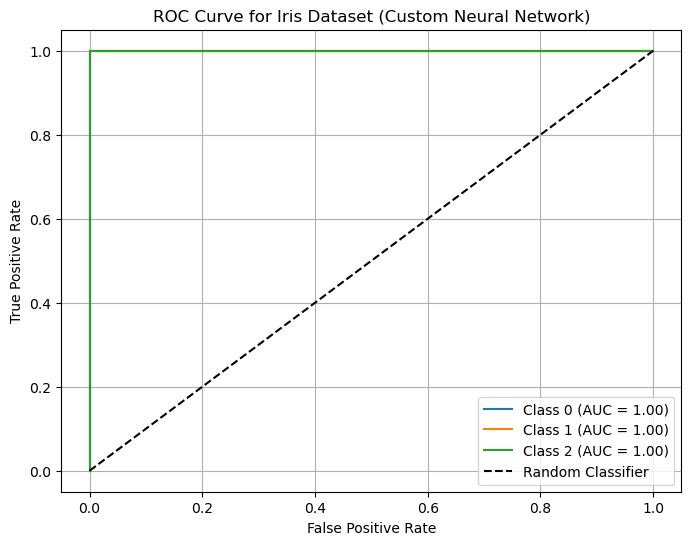

In [8]:
# Precision, F1-Score
# 'weighted' average is good for imbalanced datasets, 'macro' for balanced
print(f"Test Precision (weighted): {precision_score(y_test_true_labels, y_test_pred_labels, average='weighted'):.2f}")
print(f"Test F1-Score (weighted): {f1_score(y_test_true_labels, y_test_pred_labels, average='weighted'):.2f}")


# ROC Curve and AUC for multi-class (One-vs-Rest)
plt.figure(figsize=(8, 6))
for i in range(num_classes):
    fpr, tpr, _ = roc_curve(y_test[:, i], y_test_pred_proba[:, i])
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f'Class {i} (AUC = {roc_auc:.2f})')

plt.plot([0, 1], [0, 1], 'k--', label='Random Classifier')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve for Iris Dataset (Custom Neural Network)')
plt.legend(loc='lower right')
plt.grid(True)
plt.show()

#### Train IRIS dataset using Keras Tensorflow ####


--- Evaluation for Iris Dataset (Keras) ---
Keras Test Accuracy: 0.93
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 64ms/step
Keras Test Precision (weighted): 0.94
Keras Test F1-Score (weighted): 0.93


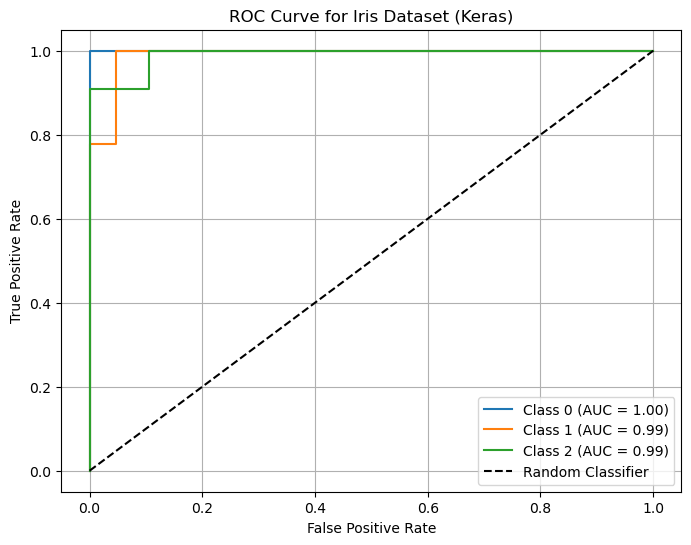

In [9]:
import tensorflow as tf
from sklearn.preprocessing import OneHotEncoder

# Load data
iris = load_iris()
X = iris.data
y = iris.target

# One-hot encode and scale
encoder = OneHotEncoder(sparse_output=False)
y_encoded_keras = encoder.fit_transform(y.reshape(-1, 1))
scaler = StandardScaler()
X_scaled_keras = scaler.fit_transform(X)

# Train-test split
X_train_keras, X_test_keras, y_train_keras, y_test_keras = train_test_split(X_scaled_keras, y_encoded_keras, test_size=0.2, random_state=42)

# Keras model
model = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(4,)),
    tf.keras.layers.Dense(8, activation='relu'),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.Dropout(0.3),
    tf.keras.layers.Dense(3, activation='softmax')
])
model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
model.fit(X_train_keras, y_train_keras, epochs=100, verbose=0)

# Evaluate the model
loss_keras, accuracy_keras = model.evaluate(X_test_keras, y_test_keras, verbose=0)
print(f"\n--- Evaluation for Iris Dataset (Keras) ---")
print(f"Keras Test Accuracy: {accuracy_keras:.2f}")

# Get predictions for other metrics
y_pred_proba_keras = model.predict(X_test_keras)
y_pred_labels_keras = np.argmax(y_pred_proba_keras, axis=1)
y_test_true_labels_keras = np.argmax(y_test_keras, axis=1)

print(f"Keras Test Precision (weighted): {precision_score(y_test_true_labels_keras, y_pred_labels_keras, average='weighted'):.2f}")
print(f"Keras Test F1-Score (weighted): {f1_score(y_test_true_labels_keras, y_pred_labels_keras, average='weighted'):.2f}")

# ROC Curve and AUC for multi-class (One-vs-Rest)
plt.figure(figsize=(8, 6))
for i in range(num_classes):
    fpr, tpr, _ = roc_curve(y_test_keras[:, i], y_pred_proba_keras[:, i])
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f'Class {i} (AUC = {roc_auc:.2f})')

plt.plot([0, 1], [0, 1], 'k--', label='Random Classifier')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve for Iris Dataset (Keras)')
plt.legend(loc='lower right')
plt.grid(True)
plt.show()

#### Train IRIS dataset using Pytorch ####


--- Training PyTorch Model on Iris Dataset ---

--- Evaluation for Iris Dataset (PyTorch) ---
PyTorch Test Accuracy: 1.00
PyTorch Test Precision (weighted): 1.00
PyTorch Test F1-Score (weighted): 1.00


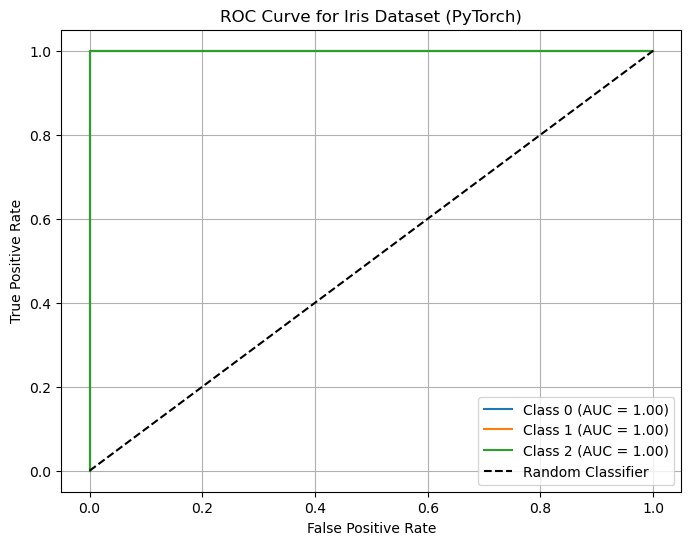

In [10]:
import torch
import torch.nn as nn
import torch.optim as optim


# Load and preprocess
iris = load_iris()
X = iris.data
y = iris.target

encoder = OneHotEncoder(sparse_output=False)
y_encoded_pt = encoder.fit_transform(y.reshape(-1, 1))
scaler = StandardScaler()
X_scaled_pt = scaler.fit_transform(X)

X_train_pt, X_test_pt, y_train_pt, y_test_pt = train_test_split(X_scaled_pt, y_encoded_pt, test_size=0.2, random_state=42)

X_train_tensor = torch.tensor(X_train_pt, dtype=torch.float32)
X_test_tensor = torch.tensor(X_test_pt, dtype=torch.float32)
y_train_labels = torch.tensor(np.argmax(y_train_pt, axis=1), dtype=torch.long) # For CrossEntropyLoss
y_test_labels = torch.tensor(np.argmax(y_test_pt, axis=1), dtype=torch.long) # For CrossEntropyLoss

# Define model
class IrisNet(nn.Module):
    def __init__(self):
        super(IrisNet, self).__init__()
        self.fc1 = nn.Linear(4, 8)
        self.bn1 = nn.BatchNorm1d(8)
        self.dropout = nn.Dropout(0.3)
        self.fc2 = nn.Linear(8, num_classes)

    def forward(self, x):
        x = torch.relu(self.fc1(x))
        x = self.bn1(x)
        x = self.dropout(x)
        return self.fc2(x)

pytorch_model = IrisNet()
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(pytorch_model.parameters(), lr=0.01)

# Training loop
print("\n--- Training PyTorch Model on Iris Dataset ---")
for epoch in range(100):
    pytorch_model.train()
    optimizer.zero_grad()
    outputs = pytorch_model(X_train_tensor)
    loss = criterion(outputs, y_train_labels)
    loss.backward()
    optimizer.step()


# Evaluation
pytorch_model.eval()
with torch.no_grad():
    y_pred_logits_pt = pytorch_model(X_test_tensor)
    y_pred_proba_pt = torch.softmax(y_pred_logits_pt, dim=1).numpy()
    y_pred_labels_pt = torch.argmax(y_pred_logits_pt, dim=1).numpy()
    y_test_true_labels_pt = y_test_labels.numpy() # True labels in original format

print(f"\n--- Evaluation for Iris Dataset (PyTorch) ---")
print(f"PyTorch Test Accuracy: {accuracy_score(y_test_true_labels_pt, y_pred_labels_pt):.2f}")
print(f"PyTorch Test Precision (weighted): {precision_score(y_test_true_labels_pt, y_pred_labels_pt, average='weighted'):.2f}")
print(f"PyTorch Test F1-Score (weighted): {f1_score(y_test_true_labels_pt, y_pred_labels_pt, average='weighted'):.2f}")

# ROC Curve and AUC for multi-class (One-vs-Rest)
plt.figure(figsize=(8, 6))
for i in range(num_classes):
    fpr, tpr, _ = roc_curve(y_test_pt[:, i], y_pred_proba_pt[:, i])
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f'Class {i} (AUC = {roc_auc:.2f})')

plt.plot([0, 1], [0, 1], 'k--', label='Random Classifier')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve for Iris Dataset (PyTorch)')
plt.legend(loc='lower right')
plt.grid(True)
plt.show()



####  Train MNIST Digits  dataset using Custom Neural network ####

In [11]:
# resetting them to True to demonstrate for MNIST grayscale dataset
sigmoid_invk = True
sigmoid_der_invk = True
relu_invk = True
relu_der_invk = True
softmax_invk = True
crs_entr_loss_invk = True
Dens_init_invk = True
Dens_frwd_invk = True
Dens_bkwd_invk = True
NN_init_invk = True
NN_fwd_invk = True
NN_bkwd_invk = True
BN_init_invk = True
BN_fwd_invk = True
BN_bkwd_invk = True
DrpLyr_init_invk = True
DrpLyr_fwd_invk = True
DrpLyr_bkwd_invk = True

Inside NeuralNetwork classs : __init__(x) function
Inside Dense_Custom classs : __init__(x) function
Inside NeuralNetwork classs : add(x) function
Inside BatchNormalizationLayer_custom classs : __init__(x) function
Inside NeuralNetwork classs : add(x) function
Inside DropoutLayer_custom classs : __init__(x) function
Inside NeuralNetwork classs : add(x) function
Inside Dense_Custom classs : __init__(x) function
Inside NeuralNetwork classs : add(x) function
Inside NeuralNetwork classs : train(x) function
Inside NeuralNetwork classs : forward(x) function
Inside Dense_Custom classs : forward(x) function
Inside Gen: relu(x) function
Inside BatchNormalizationLayer_custom classs : forward(x) function
Inside DropoutLayer_custom classs : forward(x) function
Inside Gen: softmax(x) function
Inside Gen: cross_entropy_loss(x) function
Inside NeuralNetwork classs : backward(x) function
Inside Dense_Custom classs : backward(x) function
Inside DropoutLayer_custom classs : backward(x) function
Inside B

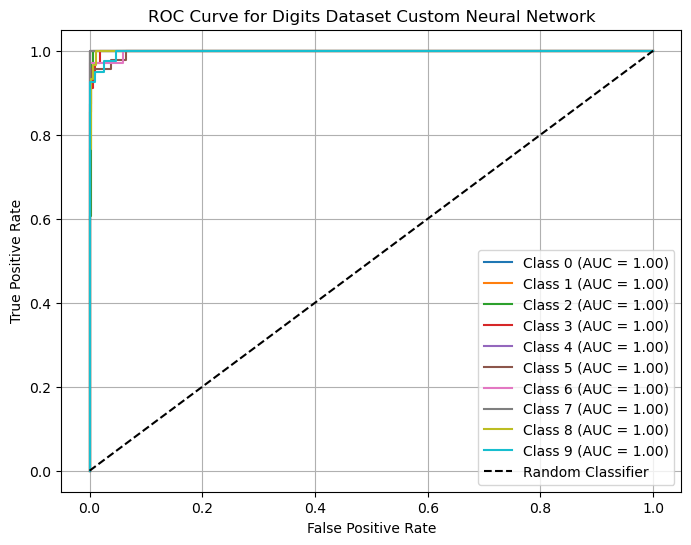

In [12]:
from sklearn.datasets import load_digits

# Load small MNIST-like digits dataset (8x8 images, 10 classes)
digits = load_digits()
X_16 = digits.data / 16.0  # Normalize pixel values from 0-16 to 0-1
y_16 = digits.target

# One-hot encode labels
num_classes = 10
encoder = OneHotEncoder(sparse_output=False)
y_encoded = encoder.fit_transform(y_16.reshape(-1, 1))

# Split into training and test sets
X_train_m1, X_test_m1, y_train_m1, y_test_m1 = train_test_split(X_16, y_encoded, train_size=0.8, random_state=42)

# Define and train the custom neural network
model = NeuralNetwork(learning_rate=0.1)
model.add(Dense_Custom(input_dim=64, output_dim=128, activation='relu'))
model.add(BatchNormalizationLayer_custom(input_dim=128))
model.add(DropoutLayer_custom(dropout_rate=0.3))
model.add(Dense_Custom(input_dim=128, output_dim=10, activation='softmax'))

model.train(X_train_m1, y_train_m1, epochs=30)

# Evaluate performance
y_pred_labels_m1 = model.predict(X_test_m1)
y_pred_proba_m1 = model.predict_proba(X_test_m1)
y_true_labels_m1 = np.argmax(y_test_m1, axis=1)

print(f"\n--- Evaluation for Digits Dataset (Custom NN) ---")
print(f"Test Accuracy: {accuracy_score(y_true_labels_m1, y_pred_labels_m1):.2f}")
print(f"Test Precision (weighted): {precision_score(y_true_labels_m1, y_pred_labels_m1, average='weighted'):.2f}")
print(f"Test F1-Score (weighted): {f1_score(y_true_labels_m1, y_pred_labels_m1, average='weighted'):.2f}")

# ROC Curve and AUC for multi-class (One-vs-Rest)
plt.figure(figsize=(8, 6))
for i in range(num_classes):
    fpr, tpr, _ = roc_curve(y_test_m1[:, i], y_pred_proba_m1[:, i])
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f'Class {i} (AUC = {roc_auc:.2f})')

plt.plot([0, 1], [0, 1], 'k--', label='Random Classifier')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve for Digits Dataset Custom Neural Network')
plt.legend(loc='lower right')
plt.grid(True)
plt.show()


In [13]:
# resetting them to True to demonstrate for MNIST  dataset training in custom Neural Network
sigmoid_invk = True
sigmoid_der_invk = True
relu_invk = True
relu_der_invk = True
softmax_invk = True
crs_entr_loss_invk = True
Dens_init_invk = True
Dens_frwd_invk = True
Dens_bkwd_invk = True
NN_init_invk = True
NN_fwd_invk = True
NN_bkwd_invk = True
BN_init_invk = True
BN_fwd_invk = True
BN_bkwd_invk = True
DrpLyr_init_invk = True
DrpLyr_fwd_invk = True
DrpLyr_bkwd_invk = True

####  Training MNIST Data on a Custom Neural Network ####
Using a custom neural network, each image is flattened into a 784-dimensional vector, and the digit labels are one-hot encoded. The model is constructed with layers such as Dense_Custom for fully connected computations, BatchNormalizationLayer_custom for input normalization, and DropoutLayer_custom to reduce overfitting.

Training involves feeding batches of these image vectors through the network, calculating predictions, computing loss using functions like cross-entropy, and performing backpropagation to update weights and parameters. Across multiple epochs, the model learns to distinguish digits with increasing accuracy. 

Inside NeuralNetwork classs : __init__(x) function
Inside Dense_Custom classs : __init__(x) function
Inside NeuralNetwork classs : add(x) function
Inside BatchNormalizationLayer_custom classs : __init__(x) function
Inside NeuralNetwork classs : add(x) function
Inside DropoutLayer_custom classs : __init__(x) function
Inside NeuralNetwork classs : add(x) function
Inside Dense_Custom classs : __init__(x) function
Inside NeuralNetwork classs : add(x) function
Inside NeuralNetwork classs : train(x) function
Inside NeuralNetwork classs : forward(x) function
Inside Dense_Custom classs : forward(x) function
Inside Gen: relu(x) function
Inside BatchNormalizationLayer_custom classs : forward(x) function
Inside DropoutLayer_custom classs : forward(x) function
Inside Gen: softmax(x) function
Inside Gen: cross_entropy_loss(x) function
Inside NeuralNetwork classs : backward(x) function
Inside Dense_Custom classs : backward(x) function
Inside DropoutLayer_custom classs : backward(x) function
Inside B

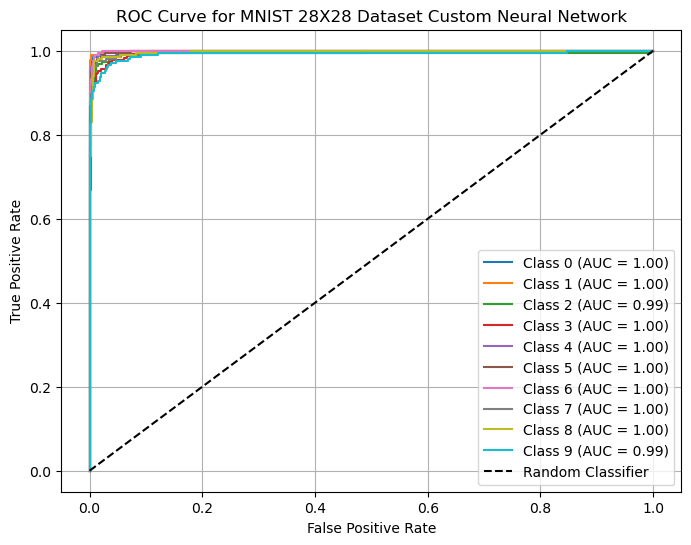

In [14]:
# Load and preprocess MNIST dataset
# Use fetch_openml to load MNIST and train the custom neural network
from sklearn.datasets import fetch_openml
mnist = fetch_openml('mnist_784', version=1, as_frame=False)
X_28 = mnist.data.astype('float32') / 255.0
y_28 = mnist.target.astype('int')

# One-hot encode labels
encoder = OneHotEncoder(sparse_output=False)
y_encoded_m2 = encoder.fit_transform(y_28.reshape(-1, 1))

# Subset for performance
X_train_m2, X_test_m2, y_train_m2, y_test_m2 = train_test_split(X_28, y_encoded_m2, train_size=10000, test_size=2000, random_state=42)

# Define and train the custom neural network
model = NeuralNetwork(learning_rate=0.1)
model.add(Dense_Custom(input_dim=784, output_dim=960, activation='relu'))
model.add(BatchNormalizationLayer_custom(input_dim=960))
model.add(DropoutLayer_custom(dropout_rate=0.3))
model.add(Dense_Custom(input_dim=960, output_dim=10, activation='softmax'))

model.train(X_train_m2, y_train_m2, epochs=20)

# Evaluate accuracy
y_pred_labels_m2 = model.predict(X_test_m2)
y_pred_proba_m2 = model.predict_proba(X_test_m2) # Get probabilities for ROC curve
y_true_labels_m2 = np.argmax(y_test_m2, axis=1)

print(f"\n--- Evaluation for MNIST Dataset (Custom NN) ---")
print(f"Test Accuracy: {accuracy_score(y_true_labels_m2, y_pred_labels_m2):.2f}")
print(f"Test Precision (weighted): {precision_score(y_true_labels_m2, y_pred_labels_m2, average='weighted'):.2f}")
print(f"Test F1-Score (weighted): {f1_score(y_true_labels_m2, y_pred_labels_m2, average='weighted'):.2f}")

# ROC Curve and AUC for multi-class (One-vs-Rest)
plt.figure(figsize=(8, 6))
for i in range(num_classes):
    fpr, tpr, _ = roc_curve(y_test_m2[:, i], y_pred_proba_m2[:, i])
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f'Class {i} (AUC = {roc_auc:.2f})')

plt.plot([0, 1], [0, 1], 'k--', label='Random Classifier')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve for MNIST 28X28 Dataset Custom Neural Network')
plt.legend(loc='lower right')
plt.grid(True)
plt.show()



In [15]:
y_28.size

70000

#### Training MNIST data using Keras Tensorflow ####

--- Keras (TensorFlow) Model on MNIST ---
Keras Model Training...
Epoch 1/10


C:\Users\poorn\AppData\Roaming\Python\Python312\site-packages\keras\src\layers\core\dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


422/422 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.8154 - loss: 0.6102 - val_accuracy: 0.9558 - val_loss: 0.1682
Epoch 2/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9469 - loss: 0.1843 - val_accuracy: 0.9712 - val_loss: 0.1063
Epoch 3/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9604 - loss: 0.1365 - val_accuracy: 0.9718 - val_loss: 0.0947
Epoch 4/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9640 - loss: 0.1184 - val_accuracy: 0.9745 - val_loss: 0.0857
Epoch 5/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9682 - loss: 0.1046 - val_accuracy: 0.9772 - val_loss: 0.0809
Epoch 6/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9724 - loss: 0.0862 - val_accuracy: 0.9773 - val_loss: 0.0789
Epoch 7/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9736 - loss: 0.0848 - val_accuracy: 0.9782 - val_loss: 0.0765
Epoch 8/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9778 - loss: 0.0715 - val_accuracy: 0.9810 - val_

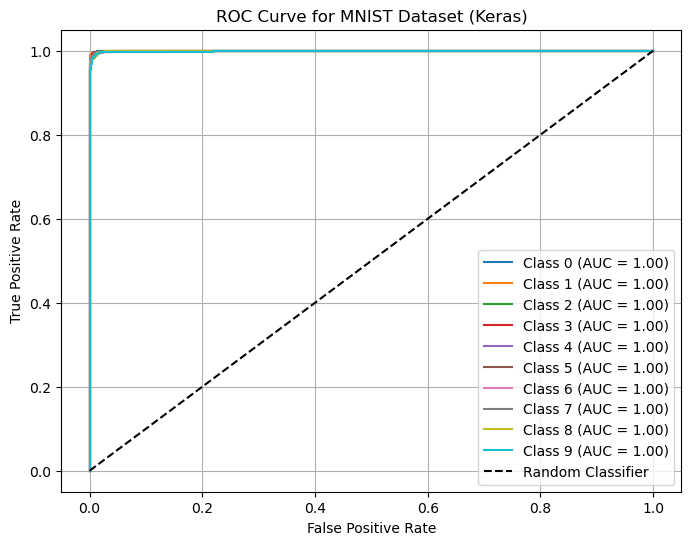

In [16]:
from tensorflow.keras.datasets import mnist
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Flatten
from tensorflow.keras.layers import Dense, BatchNormalization, Dropout

print("--- Keras (TensorFlow) Model on MNIST ---")

# Load and Preprocess MNIST data for Keras
(x_train, y_train), (x_test, y_test) = mnist.load_data()

# Normalize pixel values to 0-1 range
x_train_keras = x_train.reshape(-1, 28 * 28).astype('float32') / 255.0
x_test_keras = x_test.reshape(-1, 28 * 28).astype('float32') / 255.0

# One-hot encode labels
num_classes = 10
y_train_keras_one_hot = to_categorical(y_train, num_classes)
y_test_keras_one_hot = to_categorical(y_test, num_classes)

# Build Keras Model
keras_model = Sequential([
    Dense(128, activation='relu', input_shape=(784,)),
    BatchNormalization(),
    Dropout(0.3),
    Dense(num_classes, activation='softmax')
])

# Compile Keras Model
keras_model.compile(optimizer='adam',
                    loss='categorical_crossentropy',
                    metrics=['accuracy'])

# Train Keras Model
print("Keras Model Training...")
keras_model.fit(x_train_keras, y_train_keras_one_hot,
                epochs=10,        # Number of training epochs
                batch_size=128,   # Number of samples per gradient update
                verbose=1,        # Show progress bar
                validation_split=0.1) # Use a portion of training data for validation


# Evaluate Keras Model
loss_keras, accuracy_keras = keras_model.evaluate(x_test_keras, y_test_keras_one_hot, verbose=0)
print(f"Keras Test Accuracy: {accuracy_keras:.4f}")
print(f"Keras Test Loss: {loss_keras:.4f}")

# Get predictions for other metrics
y_pred_proba_keras = keras_model.predict(x_test_keras)
y_pred_labels_keras = np.argmax(y_pred_proba_keras, axis=1)

print(f"Keras Test Precision (weighted): {precision_score(y_test, y_pred_labels_keras, average='weighted'):.4f}")
print(f"Keras Test F1-Score (weighted): {f1_score(y_test, y_pred_labels_keras, average='weighted'):.4f}")

# ROC Curve and AUC for multi-class (One-vs-Rest)
plt.figure(figsize=(8, 6))
for i in range(num_classes):
    fpr, tpr, _ = roc_curve(y_test_keras_one_hot[:, i], y_pred_proba_keras[:, i])
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f'Class {i} (AUC = {roc_auc:.2f})')

plt.plot([0, 1], [0, 1], 'k--', label='Random Classifier')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve for MNIST Dataset (Keras)')
plt.legend(loc='lower right')
plt.grid(True)
plt.show()





#### Training MNIST data using PyTorch ####


--- PyTorch Model on MNIST ---
PyTorch Model Training...
Epoch 1/10, Loss: 0.3058
Epoch 2/10, Loss: 0.1562
Epoch 3/10, Loss: 0.1230
Epoch 4/10, Loss: 0.1042
Epoch 5/10, Loss: 0.0923
Epoch 6/10, Loss: 0.0869
Epoch 7/10, Loss: 0.0793
Epoch 8/10, Loss: 0.0724
Epoch 9/10, Loss: 0.0695
Epoch 10/10, Loss: 0.0648

PyTorch Test Accuracy: 0.9789
PyTorch Test Precision (weighted): 0.9789
PyTorch Test F1-Score (weighted): 0.9789


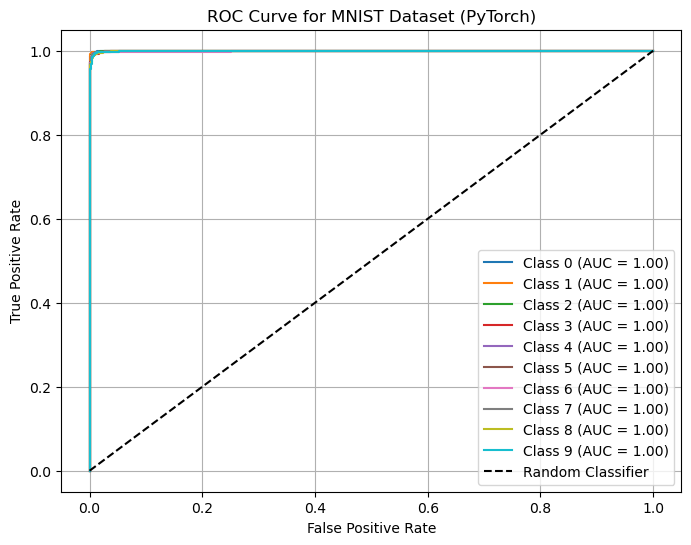

In [17]:
from torch.utils.data import DataLoader, TensorDataset

print("\n--- PyTorch Model on MNIST ---")

# Load and Preprocess MNIST data for PyTorch (use data loaded for Keras)
# convert to PyTorch tensors
x_train_pt = torch.tensor(x_train.reshape(-1, 28 * 28).astype('float32') / 255.0, dtype=torch.float32)
y_train_pt = torch.tensor(y_train, dtype=torch.long) # CrossEntropyLoss expects class indices, not one-hot
x_test_pt = torch.tensor(x_test.reshape(-1, 28 * 28).astype('float32') / 255.0, dtype=torch.float32)
y_test_pt = torch.tensor(y_test, dtype=torch.long)

# Create DataLoader for batching
train_dataset = TensorDataset(x_train_pt, y_train_pt)
test_dataset = TensorDataset(x_test_pt, y_test_pt)

batch_size_pt = 128
train_loader = DataLoader(train_dataset, batch_size=batch_size_pt, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=batch_size_pt, shuffle=False)

# Build PyTorch Model
class MNISTNet(nn.Module):
    def __init__(self):
        super(MNISTNet, self).__init__()
        self.fc1 = nn.Linear(28 * 28, 128)
        self.bn1 = nn.BatchNorm1d(128)
        self.dropout = nn.Dropout(0.3)
        self.fc2 = nn.Linear(128, num_classes)

    def forward(self, x):
        x = torch.relu(self.fc1(x))
        x = self.bn1(x)
        x = self.dropout(x)
        return self.fc2(x)

pytorch_model = MNISTNet()

# Define Loss Function and Optimizer
criterion_pt = nn.CrossEntropyLoss()
optimizer_pt = optim.Adam(pytorch_model.parameters(), lr=0.001)

# Move model to GPU if available
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
pytorch_model.to(device)
x_test_pt_device = x_test_pt.to(device) # Move test data to device for evaluation
y_test_pt_device = y_test_pt.to(device)


# Train PyTorch Model
print("PyTorch Model Training...")
epochs_pt = 10
for epoch in range(epochs_pt):
    pytorch_model.train() # Set model to training mode
    running_loss = 0.0
    for inputs, labels in train_loader:
        inputs, labels = inputs.to(device), labels.to(device)

        optimizer_pt.zero_grad()
        outputs = pytorch_model(inputs)
        loss = criterion_pt(outputs, labels)
        loss.backward()
        optimizer_pt.step()
        running_loss += loss.item() * inputs.size(0)

    epoch_loss = running_loss / len(train_dataset)
    print(f"Epoch {epoch+1}/{epochs_pt}, Loss: {epoch_loss:.4f}")


# Evaluate PyTorch Model
pytorch_model.eval() # Set model to evaluation mode
y_true_labels_pt = y_test_pt.numpy() # For metric calculation on CPU
y_test_one_hot_pt = to_categorical(y_test_pt.numpy(), num_classes) # For ROC curve

with torch.no_grad(): # Disable gradient calculation for evaluation
    y_pred_logits_pt = pytorch_model(x_test_pt_device)
    y_pred_proba_pt = torch.softmax(y_pred_logits_pt, dim=1).cpu().numpy() # Move to CPU for numpy conversion
    _, y_pred_labels_pt = torch.max(y_pred_logits_pt.data, 1)
    y_pred_labels_pt = y_pred_labels_pt.cpu().numpy()

print(f"\nPyTorch Test Accuracy: {accuracy_score(y_true_labels_pt, y_pred_labels_pt):.4f}")
print(f"PyTorch Test Precision (weighted): {precision_score(y_true_labels_pt, y_pred_labels_pt, average='weighted'):.4f}")
print(f"PyTorch Test F1-Score (weighted): {f1_score(y_true_labels_pt, y_pred_labels_pt, average='weighted'):.4f}")

# ROC Curve and AUC for multi-class (One-vs-Rest)
plt.figure(figsize=(8, 6))
for i in range(num_classes):
    fpr, tpr, _ = roc_curve(y_test_one_hot_pt[:, i], y_pred_proba_pt[:, i])
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f'Class {i} (AUC = {roc_auc:.2f})')

plt.plot([0, 1], [0, 1], 'k--', label='Random Classifier')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve for MNIST Dataset (PyTorch)')
plt.legend(loc='lower right')
plt.grid(True)
plt.show()